#### Import Libraries

In [33]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



#### Load Dataset

In [34]:
X, y = load_digits(return_X_y=True)


#### Scale Features

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#### Split into Train/Test Sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
X_train

array([[ 0.        , -0.33501649, -1.09493684, ...,  0.20951905,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  0.37766131, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.88456568, ...,  0.03999823,
        -0.5056698 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.37903986,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.88456568, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

#### Train SVM Model

In [38]:
model = SVC(kernel='linear')  # Try 'rbf' or 'poly' for nonlinear boundaries
model.fit(X_train, y_train)


SVC(kernel='linear')

#### Predict and Evaluate

In [39]:
y_pred = model.predict(X_test)

print("Accuracy: test", model.score(X_test, y_test))
print("Accuracy: train",model.score(X_train,y_train))
print(classification_report(y_test, y_pred))


Accuracy: test 0.9796296296296296
Accuracy: train 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.92      0.98      0.95        55
           2       1.00      1.00      1.00        53
           3       0.98      0.98      0.98        55
           4       1.00      1.00      1.00        54
           5       1.00      0.96      0.98        55
           6       0.98      0.98      0.98        54
           7       0.98      1.00      0.99        54
           8       1.00      0.88      0.94        52
           9       0.95      1.00      0.97        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



#### Compute Confusion Matrix

In [40]:
# y_test: true labels
# y_pred: predicted labels from SVM
cm = confusion_matrix(y_test, y_pred)


#### Visualize It

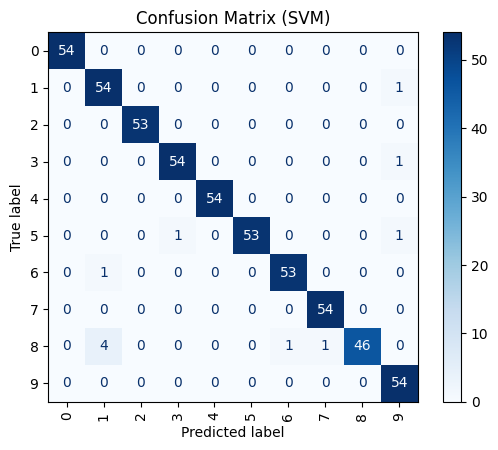

In [32]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix (SVM)")
plt.show()
